# 07. Seed Stability — How Much of the scVI / scANVI Numbers Is Noise?

Notebooks 03 and 04 report single-run numbers to three decimals and, in the same breath,
admit that they move around between runs because no seed was fixed. That's the wrong way
round: if a measurement has noise, the noise gets measured and reported, and the number
gets quoted as mean ± sd. This notebook does that.

Setup is identical to 03/04 (same HVGs, same rounding of the counts layer, same
`n_latent=30, n_layers=2`, same `max_epochs=200` with early stopping for scVI,
`max_epochs=50, n_samples_per_label=100` for scANVI, same `smartseq2` hold-out). The only
change: `scvi.settings.seed` is set explicitly, and the whole thing is repeated for five seeds.

Three things are recorded per seed that were missing before:

1. **Held-out metrics for the comparison table.** scANVI was trained with labels for ~85 %
   of the cells, so ARI/NMI computed over *all* cells is not comparable with Harmony or
   scVI (see the patched notebook 05). Here ARI/NMI are computed both over all cells (for
   continuity with 02–05) and over the held-out `smartseq2` cells only.
2. **Macro-F1 alongside accuracy.** Accuracy on this hold-out is dominated by alpha and
   beta cells (1316 of 2394). Macro-F1 weights every cell type equally and shows what
   happens to the rare ones.
3. **Training curves and early-stopping status.** `early_stopping=True` was set in 03/04,
   but both runs went the full 200 epochs. Whether that means "not converged" or "still
   improving slowly" is visible from the ELBO curves, not from the final number.

Per-cell predictions on the held-out cells are saved for every seed — notebook 08 uses
them to separate errors the model makes *consistently* (biology or annotation candidates)
from errors that come and go with the initialization (model noise).

In [1]:
import sys, warnings, time
sys.path.append("../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import matplotlib.pyplot as plt
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             accuracy_score, f1_score)

sc.settings.verbosity = 1
scvi.settings.verbosity = 30  # warnings only; training curves are plotted below instead

SEEDS = [0, 1, 2, 3, 4]
RESOLUTIONS = [0.3, 0.5]          # 0.3 was the best resolution for every method in 02–05
HOLDOUT_TECH = "smartseq2"
print("scanpy", sc.__version__, "| scvi-tools", scvi.__version__)

scanpy 1.11.5 | scvi-tools 1.4.2


## 1. Data — exactly as in 03/04

In [2]:
adata = sc.read_h5ad("../data/raw/pancreas.h5ad")
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="tech", subset=False)
adata = adata[:, adata.var["highly_variable"]].copy()
adata.layers["counts"] = np.round(adata.layers["counts"])   # same compromise as in 03/04

holdout_mask = (adata.obs["tech"] == HOLDOUT_TECH).values
adata.obs["celltype_scanvi"] = adata.obs["celltype"].astype(str)
adata.obs.loc[holdout_mask, "celltype_scanvi"] = "Unknown"

true_holdout = adata.obs.loc[holdout_mask, "celltype"].astype(str)
classes_present = sorted(true_holdout.unique())
print(adata.shape, "| held-out cells:", holdout_mask.sum(), "| cell types present in hold-out:", len(classes_present))

(16382, 2000) | held-out cells: 2394 | cell types present in hold-out: 13


## 2. Helpers

`cluster_metrics` runs Leiden on a latent representation and returns ARI/NMI against the
annotation, once over all cells and once restricted to the held-out cells. The Leiden
clustering itself is always fitted on all cells — restricting only the *evaluation* is
what makes the number comparable across supervised and unsupervised methods.

In [3]:
def cluster_metrics(ad, rep, mask, resolutions=RESOLUTIONS):
    sc.pp.neighbors(ad, use_rep=rep, key_added=rep)
    rows = []
    for res in resolutions:
        key = f"leiden_{rep}_r{res}"
        sc.tl.leiden(ad, resolution=res, flavor="igraph", n_iterations=2, directed=False,
                     key_added=key, neighbors_key=rep)
        ct, cl = ad.obs["celltype"], ad.obs[key]
        rows.append({
            "resolution": res,
            "ARI_all": adjusted_rand_score(ct, cl),
            "NMI_all": normalized_mutual_info_score(ct, cl),
            "ARI_heldout": adjusted_rand_score(ct[mask], cl[mask]),
            "NMI_heldout": normalized_mutual_info_score(ct[mask], cl[mask]),
            "n_clusters": cl.nunique(),
        })
    return rows


def best_row(rows):
    # same rule as 02–05: pick the resolution with the highest all-cell ARI
    return max(rows, key=lambda r: r["ARI_all"])

## 3. Five seeds, same recipe each time

Roughly 25 minutes per seed on a 2-core CPU (about half that on a modern laptop).

In [4]:
records = []
histories = {}
holdout_preds = pd.DataFrame(index=adata.obs_names[holdout_mask])
holdout_preds["celltype"] = true_holdout.values

for seed in SEEDS:
    t0 = time.time()
    scvi.settings.seed = seed

    # ---- scVI --------------------------------------------------------------
    scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="tech")
    vae = scvi.model.SCVI(adata, n_latent=30, n_layers=2)
    vae.train(max_epochs=200, early_stopping=True, enable_progress_bar=False)
    adata.obsm["X_scVI"] = vae.get_latent_representation()
    scvi_rows = cluster_metrics(adata, "X_scVI", holdout_mask)
    n_epochs_scvi = len(vae.history["elbo_train"])
    histories[("scVI", seed)] = {
        "elbo_train": vae.history["elbo_train"].iloc[:, 0].values,
        "elbo_validation": vae.history["elbo_validation"].iloc[:, 0].values,
    }
    b = best_row(scvi_rows)
    records.append({"method": "scVI", "seed": seed, "epochs": n_epochs_scvi,
                    "early_stopped": n_epochs_scvi < 200, **b})

    # ---- scANVI on top of it ---------------------------------------------------
    lvae = scvi.model.SCANVI.from_scvi_model(vae, unlabeled_category="Unknown",
                                            labels_key="celltype_scanvi")
    lvae.train(max_epochs=50, n_samples_per_label=100, enable_progress_bar=False)
    adata.obsm["X_scANVI"] = lvae.get_latent_representation()
    scanvi_rows = cluster_metrics(adata, "X_scANVI", holdout_mask)
    histories[("scANVI", seed)] = {
        "classification_loss": lvae.history["train_classification_loss"].iloc[:, 0].values,
        "elbo_train": lvae.history["elbo_train"].iloc[:, 0].values,
    }

    soft = lvae.predict(soft=True)              # per-class probabilities, all cells
    pred = soft.idxmax(axis=1)
    conf = soft.max(axis=1)
    pred_ho, conf_ho = pred[holdout_mask], conf[holdout_mask]
    holdout_preds[f"pred_seed{seed}"] = pred_ho.values
    holdout_preds[f"conf_seed{seed}"] = conf_ho.values

    b = best_row(scanvi_rows)
    records.append({
        "method": "scANVI", "seed": seed, "epochs": 50, "early_stopped": False, **b,
        "accuracy_heldout": accuracy_score(true_holdout, pred_ho),
        "macroF1_heldout": f1_score(true_holdout, pred_ho, average="macro", labels=classes_present),
        "mean_confidence_heldout": float(conf_ho.mean()),
    })
    print(f"seed {seed}: scVI ARI_all={records[-2]['ARI_all']:.3f} (epochs={n_epochs_scvi}) | "
          f"scANVI acc={records[-1]['accuracy_heldout']:.3f} macroF1={records[-1]['macroF1_heldout']:.3f} | "
          f"{(time.time()-t0)/60:.1f} min")

results = pd.DataFrame(records)
results

Seed set to 0


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer.fit` stopped: `max_epochs=200` reached.


...

TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer.fit` stopped: `max_epochs=50` reached.


seed 4: scVI ARI_all=0.950 (epochs=200) | scANVI acc=0.974 macroF1=0.938 | 24.4 min


,method,seed,epochs,early_stopped,resolution,ARI_all,NMI_all,ARI_heldout,NMI_heldout,n_clusters,accuracy_heldout,macroF1_heldout,mean_confidence_heldout
0,scVI,0,200,False,0.3,0.948228,0.916238,0.949469,0.931911,13,NaN,NaN,NaN
1,scANVI,0,50,False,0.3,0.956097,0.934118,0.940279,0.921787,13,0.975773,0.935010,0.992044
2,scVI,1,200,False,0.3,0.944615,0.911289,0.945374,0.925002,10,NaN,NaN,NaN
3,scANVI,1,50,False,0.3,0.954821,0.933621,0.949493,0.934710,13,0.973684,0.934891,0.990725
4,scVI,2,200,False,0.3,0.948100,0.917399,0.951735,0.935060,13,NaN,NaN,NaN
5,scANVI,2,50,False,0.3,0.959360,0.941157,0.954031,0.943326,13,0.977026,0.959337,0.993626
6,scVI,3,200,False,0.3,0.947171,0.917021,0.947307,0.933275,12,NaN,NaN,NaN
7,scANVI,3,50,False,0.3,0.953582,0.934275,0.951139,0.937647,15,0.979950,0.949362,0.994887
8,scVI,4,200,False,0.3,0.949842,0.918544,0.952508,0.936337,11,NaN,NaN,NaN
9,scANVI,4,50,False,0.3,0.954325,0.927718,0.941419,0.924015,12,0.973684,0.938111,0.990646


## 4. Mean ± sd — the numbers that should have been in the README from the start

In [5]:
metric_cols = ["ARI_all", "NMI_all", "ARI_heldout", "NMI_heldout",
               "accuracy_heldout", "macroF1_heldout", "mean_confidence_heldout"]
summary = (results.groupby("method")[metric_cols]
           .agg(["mean", "std"])
           .round(4))
summary.columns = [f"{m}_{s}" for m, s in summary.columns]
summary = summary.loc[["scVI", "scANVI"]]

def fmt(m, s):
    return "—" if np.isnan(m) else f"{m:.3f} ± {s:.3f}"

table = pd.DataFrame({
    col: [fmt(summary.loc[meth, f"{col}_mean"], summary.loc[meth, f"{col}_std"]) for meth in summary.index]
    for col in metric_cols
}, index=summary.index)
print(table.to_markdown())
print("\nEpochs trained (scVI):", results.loc[results.method == "scVI", "epochs"].tolist(),
      "| early-stopped:", results.loc[results.method == "scVI", "early_stopped"].tolist())

results.to_csv("../results/seed_stability.csv", index=False)
summary.to_csv("../results/seed_stability_summary.csv")
holdout_preds.to_csv("../results/seed_predictions_smartseq2.csv")
print("Saved: results/seed_stability.csv, seed_stability_summary.csv, seed_predictions_smartseq2.csv")

| method   | ARI_all       | NMI_all       | ARI_heldout   | NMI_heldout   | accuracy_heldout   | macroF1_heldout   | mean_confidence_heldout   |
|:---------|:--------------|:--------------|:--------------|:--------------|:-------------------|:------------------|:--------------------------|
| scVI     | 0.948 ± 0.002 | 0.916 ± 0.003 | 0.949 ± 0.003 | 0.932 ± 0.004 | —                  | —                 | —                         |
| scANVI   | 0.956 ± 0.002 | 0.934 ± 0.005 | 0.947 ± 0.006 | 0.932 ± 0.009 | 0.976 ± 0.003      | 0.943 ± 0.011     | 0.992 ± 0.002             |

Epochs trained (scVI): [200, 200, 200, 200, 200] | early-stopped: [False, False, False, False, False]
Saved: results/seed_stability.csv, seed_stability_summary.csv, seed_predictions_smartseq2.csv


## 5. Training curves

If the validation ELBO is still falling at epoch 200, the model is under-trained and the
"200 epochs reached" message from 03/04 was a warning, not a formality. If it has
flattened, early stopping simply never met its patience criterion (45 epochs without
improvement) — harmless, but worth knowing which of the two it is.

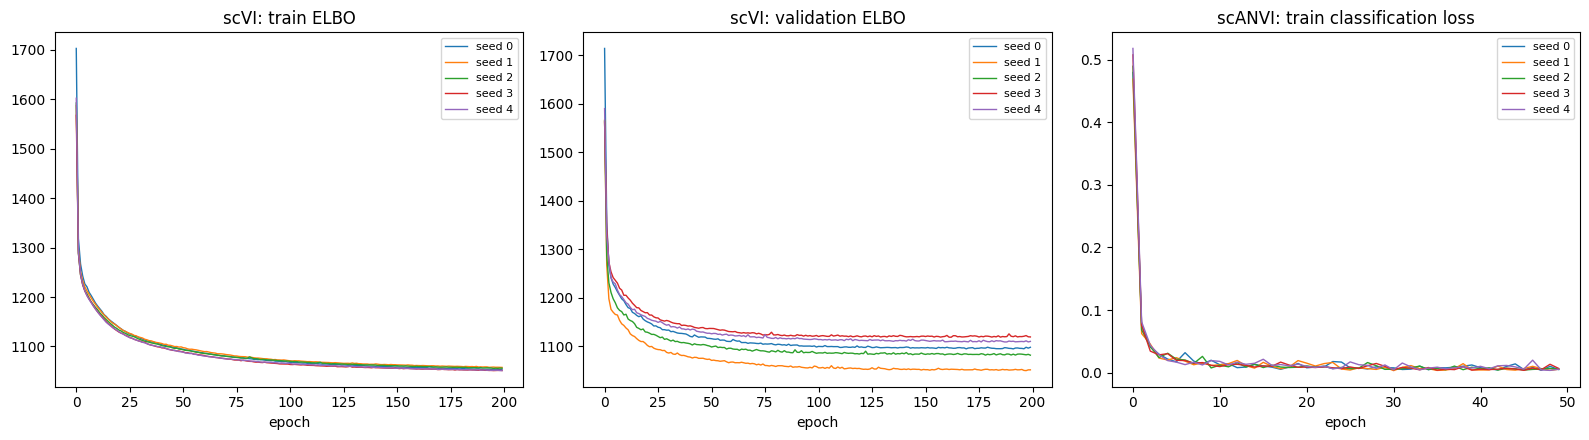

Share of the total validation-ELBO drop that happened in the last 50 epochs, per seed:
{0: -0.0018, 1: 0.0016, 2: 0.0052, 3: 0.0038, 4: 0.0056}


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for (method, seed), h in histories.items():
    if method == "scVI":
        axes[0].plot(h["elbo_train"], lw=1, label=f"seed {seed}")
        axes[1].plot(h["elbo_validation"], lw=1, label=f"seed {seed}")
    else:
        axes[2].plot(h["classification_loss"], lw=1, label=f"seed {seed}")
axes[0].set_title("scVI: train ELBO"); axes[1].set_title("scVI: validation ELBO")
axes[2].set_title("scANVI: train classification loss")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../results/figures/07_training_curves.png", dpi=150)
plt.show()

# how much did the validation ELBO change over the last 50 epochs, relative to its range?
def tail_share(v, k=50):
    k = min(k, len(v) - 1)
    return (v[-k - 1] - v[-1]) / (v[0] - v[-1])

tail = {seed: tail_share(h["elbo_validation"]) for (m, seed), h in histories.items() if m == "scVI"}
print("Share of the total validation-ELBO drop that happened in the last 50 epochs, per seed:")
print({k: round(float(v), 4) for k, v in tail.items()})

## 6. Spread across seeds, per metric

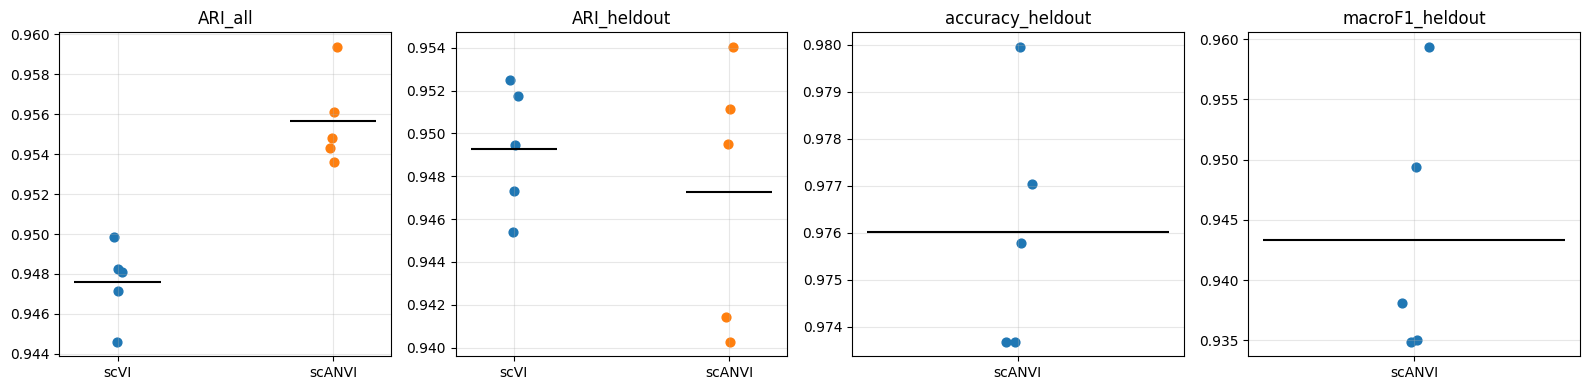

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
panels = [("ARI_all", ["scVI", "scANVI"]), ("ARI_heldout", ["scVI", "scANVI"]),
          ("accuracy_heldout", ["scANVI"]), ("macroF1_heldout", ["scANVI"])]
for ax, (col, methods) in zip(axes, panels):
    for i, m in enumerate(methods):
        vals = results.loc[results.method == m, col].values
        ax.scatter(np.full(len(vals), i) + np.random.default_rng(0).normal(0, 0.03, len(vals)), vals, s=40)
        ax.hlines(vals.mean(), i - 0.2, i + 0.2, color="k")
    ax.set_xticks(range(len(methods))); ax.set_xticklabels(methods)
    ax.set_title(col); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/07_seed_spread.png", dpi=150)
plt.show()

## Conclusions

**Spread.** Five seeds, identical recipe: scVI ARI 0.948 ± 0.002 / NMI 0.916 ± 0.003;
scANVI ARI 0.956 ± 0.002 / NMI 0.934 ± 0.005; scANVI held-out accuracy 0.976 ± 0.003 and
macro-F1 0.943 ± 0.011. The third decimal of any single run is noise, as suspected in 03/04 —
but the noise is small: one standard deviation is 0.002–0.005 on ARI/NMI and 0.3 percentage
points on accuracy. The single runs in 03/04 (scVI 0.947, scANVI 0.950; accuracy 0.975) sit
inside this spread. Macro-F1 is the least stable number (sd 0.011), because it is driven by
cell types with a handful of held-out cells (mast 7, schwann 2, epsilon 8).

**scANVI ≥ scVI holds on all-cell ARI in every seed, but that is not a fair comparison** —
scANVI was trained with 85 % of the labels. Restricted to the held-out `smartseq2` cells,
where neither model saw a label, the two are indistinguishable: 0.949 ± 0.003 vs
0.947 ± 0.006. What supervision buys is visible in the all-cell numbers only.

**Training.** No seed triggered early stopping; the validation ELBO is flat from roughly
epoch 100 onward (the last 50 epochs contribute < 0.6 % of the total drop), so "200 epochs
reached" meant "converged, patience never expired", not "under-trained". The different
validation-ELBO levels per seed are different random validation splits, not different
fits — train ELBO is identical across seeds. scANVI's classification loss on the labelled
cells is ~0 after ten epochs: the classifier memorizes the reference labels, which is also
why its mean confidence on the held-out cells is 0.992. High confidence here is a property
of the training regime, not evidence of correctness — notebook 08 checks whether the
stable errors are among the few lower-confidence cells.

**What this changes in the README.** Single-run numbers are replaced by mean ± sd; the
scANVI-vs-scVI comparison is reported on held-out cells; per-cell predictions for all five
seeds are saved for the error anatomy in 08.